In [2]:
import pandas as pd

In [5]:
import sys
import os

# 현재 작업 디렉터리를 기준으로 utils 경로 추가
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'utils')))

from data_utils import *  # utils/data_utils.py

In [3]:
data = pd.read_csv('../data/2월이후guest.csv')

In [4]:
data.head()

,customerId,AVG(fo.storeId),fullName,MIN(fo.createdAt),orders_count_per_customer
0,01JR4YRCW1XC0QE1FFDPAQ2PS3,10028.0,G***t,2025-04-06 07:06:36.835488,48
1,01JKSDCD52SAQ2BFTRDXFPX24F,10028.0,G***t,2025-02-11 02:28:32.182984,22
2,01JMNNE6KSFFEJEJ20S5Z4G4KG,10028.0,G***t,2025-02-22 01:48:03.664333,16
3,01JNMT2YBEHYJ8NQ377VVSWC2D,10028.0,G***t,2025-03-06 04:05:44.979583,11
4,01JM1TXGNGZD6RAPM0VKJCXA18,10028.0,G***t,2025-02-14 08:58:59.656950,10


🧼 [결측치 비율 확인]


📊 [숫자형 변수 이상값 리포트]

📌 AVG(fo.storeId)
 - Median: 10028.00
 - Max: 10028.00 / Min: 3.00
 - Mean ± 3*Std: [-8449.89, 20798.74]
   → ✅ 정상 범위 내
 - Z-score > 3: 0건
   → ✅ Z-score 이상 없음
 - IQR 범위: [-15034.50, 25065.50]
 - IQR 기준 이상값: 0건
   → ✅ IQR 기준 이상 없음



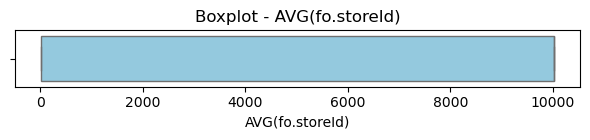

📌 orders_count_per_customer
 - Median: 1.00
 - Max: 48.00 / Min: 1.00
 - Mean ± 3*Std: [-1.38, 3.82]
   → 🚨 이상값 의심됨 (3*표준편차 범위 초과)
 - Z-score > 3: 104건
   → 🚨 이상값 의심됨 (Z-score 기준)
 - IQR 범위: [1.00, 1.00]
 - IQR 기준 이상값: 1176건
   → 🚨 이상값 의심됨 (IQR 기준)



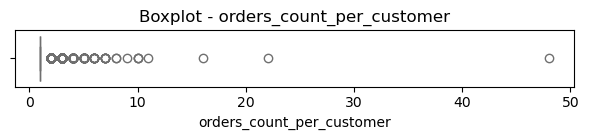


📦 [범주형 변수 희귀값 확인] (비율 < 1.0%)
 - customerId: 희귀값 8097개 (100.0%) → ⚠️ 희귀 범주 존재
 - fullName: ✅ 전부 적정 분포
 - MIN(fo.createdAt): 희귀값 8097개 (100.0%) → ⚠️ 희귀 범주 존재


In [6]:
detailed_outlier_report(data)

In [9]:
import pandas as pd, numpy as np, math

s  = data['orders_count_per_customer']

# 1) 분위수 확인
print(s.describe())
print(s.quantile([.95,.97,.99,.999]))

# 2) 극보수적 임계값: 99.9-percentile = 8
threshold = 9
outliers  = data[data['orders_count_per_customer'] >= threshold]

# 3) Poisson 검정
mu = s.mean()
p_ge9 = 1 - sum(math.exp(-mu)*mu**k/math.factorial(k) for k in range(9))
print(f'P(X≥9)  under Poisson(λ={mu:.3f}): {p_ge9:.2e}')
print(f'Expected count            : {p_ge9*len(s):.2f}')

print(f'\nOutliers (≥{threshold} orders) — {len(outliers)} rows:')
print(outliers[['customerId','orders_count_per_customer']])

count    8097.000000
mean        1.218105
std         0.865656
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        48.000000
Name: orders_count_per_customer, dtype: float64
0.950    2.0
0.970    3.0
0.990    4.0
0.999    8.0
Name: orders_count_per_customer, dtype: float64
P(X≥9)  under Poisson(λ=1.218): 5.47e-06
Expected count            : 0.04

Outliers (≥9 orders) — 8 rows:
                   customerId  orders_count_per_customer
0  01JR4YRCW1XC0QE1FFDPAQ2PS3                         48
1  01JKSDCD52SAQ2BFTRDXFPX24F                         22
2  01JMNNE6KSFFEJEJ20S5Z4G4KG                         16
3  01JNMT2YBEHYJ8NQ377VVSWC2D                         11
4  01JM1TXGNGZD6RAPM0VKJCXA18                         10
5  01JM40WGE0BVR8NZET7KXK1ND5                         10
6  01JNJJ1PHRWBFMFNWKG4QVP5J4                         10
7  01JTD221NBT3Y2J0YAVNBWRBVZ                          9


In [7]:
data[data['orders_count_per_customer']>=9]

,customerId,AVG(fo.storeId),fullName,MIN(fo.createdAt),orders_count_per_customer
0,01JR4YRCW1XC0QE1FFDPAQ2PS3,10028.0,G***t,2025-04-06 07:06:36.835488,48
1,01JKSDCD52SAQ2BFTRDXFPX24F,10028.0,G***t,2025-02-11 02:28:32.182984,22
2,01JMNNE6KSFFEJEJ20S5Z4G4KG,10028.0,G***t,2025-02-22 01:48:03.664333,16
3,01JNMT2YBEHYJ8NQ377VVSWC2D,10028.0,G***t,2025-03-06 04:05:44.979583,11
4,01JM1TXGNGZD6RAPM0VKJCXA18,10028.0,G***t,2025-02-14 08:58:59.656950,10
5,01JM40WGE0BVR8NZET7KXK1ND5,10028.0,G***t,2025-02-15 05:21:46.971536,10
6,01JNJJ1PHRWBFMFNWKG4QVP5J4,10028.0,G***t,2025-03-05 07:06:46.746549,10
7,01JTD221NBT3Y2J0YAVNBWRBVZ,10028.0,G***t,2025-05-04 07:09:37.859205,9


In [12]:
data[data['orders_count_per_customer']>=9]['customerId'].tolist()

['01JR4YRCW1XC0QE1FFDPAQ2PS3',
 '01JKSDCD52SAQ2BFTRDXFPX24F',
 '01JMNNE6KSFFEJEJ20S5Z4G4KG',
 '01JNMT2YBEHYJ8NQ377VVSWC2D',
 '01JM1TXGNGZD6RAPM0VKJCXA18',
 '01JM40WGE0BVR8NZET7KXK1ND5',
 '01JNJJ1PHRWBFMFNWKG4QVP5J4',
 '01JTD221NBT3Y2J0YAVNBWRBVZ']